# Exploratory Data Analysis 

Analysis by Dustin Keate<br>
BSDA Program, WGU

## Data Description

https://www.kaggle.com/datasets/uradkr/s-and-p-500-analyst-rating-and-price-target-accuracy

164,231 sell-side analyst rating actions on S&P 500 stocks from 307 firms, December 2011 to June 2026. Every upgrade, downgrade, and initiation is matched against realized forward stock returns at 30, 90, 180, and 365 days — producing a directional accuracy flag per call. Analysts were right 48.8% of the time at 30 days, rising to 57.0% at one year.

## Packages Used

In [32]:
import pandas as pd
import datetime as dt
from dotenv import load_dotenv
import os
import requests
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

## Initial Examination

Ingest ```.csv``` data and take an initial look at its size, structure, and completeness.

In [33]:
df = pd.read_csv('../data/sp_500_analyst_rating_and_price_target_accuracy.csv')
df.sample(10)

,ticker,event_date,firm,from_grade,to_grade,action,price_target_action,current_price_target,prior_price_target,implied_direction,forward_return_30d_pct,forward_return_90d_pct,forward_return_180d_pct,forward_return_365d_pct,accuracy_30d,accuracy_90d,accuracy_180d,accuracy_365d
46189,DHI,2024-04-04 14:04:32,Barclays,Overweight,Overweight,main,Raises,186.0,166.0,1,-2.914825,-12.690086,23.902602,-17.350821,0.0,0.0,1.0,0.0
64647,FLEX,2014-07-25 04:22:28,Deutsche Bank,NaN,Hold,main,Raises,12.0,9.0,0,0.000000,0.000000,-2.162157,-4.234233,NaN,NaN,NaN,NaN
38723,CRWD,2024-03-06 17:40:12,UBS,Buy,Buy,main,Raises,430.0,385.0,1,-4.269201,-7.279188,-19.106715,5.510211,0.0,0.0,0.0,1.0
142758,TROW,2020-01-30 13:21:49,Wells Fargo,NaN,Overweight,main,Raises,152.0,146.0,1,-8.120389,-13.539939,-0.207398,18.137235,0.0,0.0,0.0,1.0
131824,SJM,2022-11-15 13:02:35,Exane BNP Paribas,NaN,Underperform,init,Announces,138.0,0.0,-1,9.524496,7.119074,12.185090,-18.675083,0.0,0.0,0.0,1.0
30354,CI,2019-01-14 14:26:42,Stephens & Co.,NaN,Overweight,init,Announces,251.0,0.0,1,-1.692255,-14.678433,-7.798398,6.868067,0.0,0.0,0.0,1.0
121787,PNC,2014-10-20 19:15:25,Deutsche Bank,Buy,Hold,down,Lowers,87.0,94.0,-1,0.000000,-6.304700,1.790987,-0.920419,0.0,1.0,0.0,1.0
158600,WFC,2026-03-23 17:59:15,Goldman Sachs,Buy,Buy,main,Lowers,93.0,109.0,1,2.938182,NaN,NaN,NaN,1.0,NaN,NaN,NaN
36480,COST,2019-09-11 10:33:13,Oppenheimer,Outperform,Perform,down,Raises,300.0,295.0,-1,2.377144,1.972080,4.329075,17.822847,0.0,0.0,0.0,0.0
148312,UBER,2022-08-01 12:29:37,Deutsche Bank,NaN,Buy,main,Lowers,40.0,50.0,1,16.910568,8.008127,20.447149,89.634150,1.0,1.0,1.0,1.0


In [34]:
df.shape

(164231, 18)

In [35]:
df.dtypes

ticker                         str
event_date                     str
firm                           str
from_grade                     str
to_grade                       str
action                         str
price_target_action            str
current_price_target       float64
prior_price_target         float64
implied_direction            int64
forward_return_30d_pct     float64
forward_return_90d_pct     float64
forward_return_180d_pct    float64
forward_return_365d_pct    float64
accuracy_30d               float64
accuracy_90d               float64
accuracy_180d              float64
accuracy_365d              float64
dtype: object

In [36]:
df.count()

ticker                     164231
event_date                 164231
firm                       164222
from_grade                  94124
to_grade                   164096
action                     164231
price_target_action        151448
current_price_target       164231
prior_price_target         164231
implied_direction          164231
forward_return_30d_pct     162815
forward_return_90d_pct     158629
forward_return_180d_pct    153242
forward_return_365d_pct    142009
accuracy_30d               116592
accuracy_90d               113769
accuracy_180d              110064
accuracy_365d              102310
dtype: int64

In [37]:
df.nunique()

ticker                        502
event_date                 152609
firm                          306
from_grade                     46
to_grade                       46
action                          5
price_target_action             8
current_price_target         2210
prior_price_target           2185
implied_direction               3
forward_return_30d_pct     100826
forward_return_90d_pct      99076
forward_return_180d_pct     96950
forward_return_365d_pct     92259
accuracy_30d                    2
accuracy_90d                    2
accuracy_180d                   2
accuracy_365d                   2
dtype: int64

In [38]:
df.groupby('firm').agg(total_calls=('ticker', 'count')).sample(10)

,total_calls
firm,
Standpoint Research,198
J. Safra Sarasin,3
Sterne Agee,325
Global Hunter Securities,8
Pareto Securities,4
Canaccord Genuity,1000
Topeka Capital,78
Sidoti & Co.,29
DNB Markets,10


Initial Observations:

1. There are ```164231``` entries with 18 different columns consisting of entry metadata, analyst predictions (from and to), ```forward_return``` percentage, and ```accuracy``` assessments.
2. ```event_date``` column is a ```str``` object. The entries will be more valuable as a ```datetime``` object if date becomes relevant.
3. 9 rows are missing the ```firm``` entry.
4. ```forward_return``` percentage drops off naturally as the prediction ```event_date``` is closer to the end date of the data set. Data cannot exist without time travel.
5. It appears an abnormal number of rows are missing ```accuracy``` entries. This warrants additional investigation.
6. Many firms do not have a statistically relevant number of predictions.


In [39]:
df[df['firm'].isna()]

,ticker,event_date,firm,from_grade,to_grade,action,price_target_action,current_price_target,prior_price_target,implied_direction,forward_return_30d_pct,forward_return_90d_pct,forward_return_180d_pct,forward_return_365d_pct,accuracy_30d,accuracy_90d,accuracy_180d,accuracy_365d
6190,AEP,2014-11-06 10:53:04,NaN,Outperform,Market Perform,down,NaN,0.0,0.0,-1,0.000000,1.749783,-7.802993,-8.394161,0.0,0.0,1.0,1.0
27686,CCL,2016-11-22 23:30:53,NaN,Market Perform,Market Outperform,up,NaN,0.0,0.0,1,1.236219,7.958269,20.612376,32.328741,1.0,1.0,1.0,1.0
45738,DG,2016-10-10 13:06:15,NaN,NaN,Hold,main,Lowers,0.0,0.0,0,3.011064,6.569461,0.919371,18.244725,NaN,NaN,NaN,NaN
70052,GOOG,2012-07-17 13:33:00,NaN,NaN,Outperform,main,Lowers,730.0,750.0,1,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
105166,MU,2015-07-28 17:43:00,NaN,NaN,Buy,up,NaN,0.0,0.0,1,-20.658216,-16.050641,-46.936703,-28.151899,0.0,0.0,0.0,0.0
105561,NCLH,2016-11-22 23:31:58,NaN,Outperform,Market Perform,down,NaN,0.0,0.0,-1,7.776400,19.751555,25.490679,37.416152,0.0,0.0,0.0,0.0
111034,NTRS,2016-10-10 13:06:14,NaN,NaN,Hold,main,Raises,0.0,0.0,0,7.048716,24.113923,19.741670,31.783742,NaN,NaN,NaN,NaN
132928,SNPS,2016-10-10 13:08:22,NaN,NaN,Buy,main,Raises,0.0,0.0,1,-2.542934,-0.792602,17.800520,36.525757,0.0,0.0,1.0,1.0
138842,TEL,2014-01-22 13:00:00,NaN,Hold,Buy,up,Raises,75.0,55.0,1,0.000000,0.000000,0.000000,-0.585740,0.0,0.0,0.0,0.0


Rows that are missing ```firm``` entries are not abnormal except for the identified missing entry. Since the ```firm``` column is a critical element of my hypothesis, remove those rows.

In [40]:
df[df['accuracy_30d'].isna()].sample(10)

,ticker,event_date,firm,from_grade,to_grade,action,price_target_action,current_price_target,prior_price_target,implied_direction,forward_return_30d_pct,forward_return_90d_pct,forward_return_180d_pct,forward_return_365d_pct,accuracy_30d,accuracy_90d,accuracy_180d,accuracy_365d
74542,HIG,2024-10-09 18:09:46,Jefferies,Hold,Hold,main,Raises,127.0,113.0,0,0.980300,-5.854604,-4.736307,13.772395,NaN,NaN,NaN,NaN
6530,AFL,2023-02-06 14:20:09,Truist Securities,NaN,Hold,main,Raises,70.0,65.0,0,-4.407273,-2.209757,13.416632,13.136521,NaN,NaN,NaN,NaN
83868,JCI,2026-05-07 21:02:54,Citigroup,Neutral,Neutral,main,Raises,155.0,150.0,0,3.447040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
104049,MTB,2023-04-18 15:52:14,DA Davidson,NaN,Neutral,main,Lowers,138.0,141.0,0,-2.529231,5.565768,-0.394177,15.139238,NaN,NaN,NaN,NaN
25288,CAH,2023-07-11 11:43:03,Mizuho,Neutral,Neutral,main,Raises,94.0,85.0,0,-2.140755,-3.288897,12.665892,3.393094,NaN,NaN,NaN,NaN
7041,AIG,2012-05-04 11:43:00,UBS,NaN,Neutral,main,Raises,34.0,29.0,0,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
52630,EBAY,2020-06-05 14:00:07,SunTrust Robinson Humphrey,NaN,Hold,main,Raises,50.0,40.0,0,15.055306,9.211764,5.823112,35.718617,NaN,NaN,NaN,NaN
119781,PGR,2012-05-16 16:07:00,B of A Securities,NaN,Neutral,main,Lowers,24.0,25.0,0,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
144358,TSLA,2023-07-20 10:14:37,Needham,NaN,Hold,reit,NaN,0.0,0.0,0,-12.027385,-7.691138,-16.352222,-9.014834,NaN,NaN,NaN,NaN
158288,WEC,2014-10-31 13:00:00,Deutsche Bank,NaN,Hold,main,Raises,48.0,47.0,0,0.000000,8.046677,-5.443515,-0.222884,NaN,NaN,NaN,NaN


According to this sample, all entries that do not have ```accuracy``` entries are either:
- Missing associated ```forward_return``` entries for reasons already discussed, OR
- Have a ```to_grade``` entry that is associated with a neutral outlook, such as "Equal-Weight," "Hold," or "Neutral."

Both of these are normal and explainable.

**A new observation**: Many rows that have ```event_dates``` prior to approximately 1 Jan 2015 have ```forward_return``` percentages of ```0.0```.

## Initial Data Cleaning

Before performing a more complex analysis, cleaning steps identified above will be completed.

1. Convert ```event_date``` from a ```str``` object to a ```datetime``` object.
2. Remove entries with a missing ```firm``` entry.

In [41]:
df['event_date'] = pd.to_datetime(df['event_date'], format='%Y-%m-%d %H:%M:%S')

df.dropna(subset=['firm'], inplace=True)

## Further Examination of Cleaned Data

In [42]:
df[(df['event_date'] < dt.datetime(2014, 12, 5)) & (df['event_date'] > dt.datetime(2014, 12, 3))][['event_date', 'forward_return_30d_pct', 'accuracy_30d']].sample(10)

,event_date,forward_return_30d_pct,accuracy_30d
78776,2014-12-03 05:00:00,0.000000,0.0
62748,2014-12-04 13:36:58,-1.536689,0.0
142237,2014-12-04 12:16:30,-7.351048,NaN
90344,2014-12-04 12:59:59,-0.984888,NaN
160427,2014-12-04 05:00:00,-0.291056,1.0
16804,2014-12-04 14:00:00,-1.598547,NaN
15443,2014-12-04 14:00:00,1.202769,NaN
150322,2014-12-03 14:00:00,0.000000,0.0
20810,2014-12-04 13:19:15,-0.543874,0.0
2518,2014-12-04 12:58:35,0.022278,1.0


In [43]:
df[df['event_date'] < dt.datetime(2014, 12, 4)].shape

(17723, 18)

Rows with an ```event_date``` on or before ```2014-12-03``` are missing critical ```forward_return``` data that will likely be relevant when performing further analysis.

The original dataset has ```164231``` rows. The missing data affects ```17723``` rows. Removing this will represent a data loss of under 11%.

The dataset contains ratings from December 2011 to June 2026. Of this, December 2011 to November 2014 are missing data. This represents a loss of about 36 months of the 175 months represented, about 20%.

## Further Data Cleaning

Remove rows missing accurate ```forward_return``` entries.

In [44]:
df=df[df['event_date'] > dt.datetime(2014, 12, 4)]
df.shape

(146499, 18)

## S&P 500 Performance Periods

The goal of this section is to identify periods of S&P 500 negative performance as defined by Yardeni Research. This financial consultant describes two types of market losses. One is a market correction which is a loss of 10-20%, and the other is a bear market which is a loss of over 20% (2024).

To define these periods for possible use in my analysis, this requires:

1. Access FMP API @ https://site.financialmodelingprep.com/developer/docs and save data to ```.json``` file to prevent multiple API hits.
2. Load into DataFrame and perform minimal cleaning for analysis. Useing closing price, as described by Evest (2024).
3. Identify market corrections and bear markets.
4. Create DataFrame and save to ```.json```.

In [45]:
# # This was only run once to get the data from FMP API and save it to a JSON file.
# # The code is commented out to avoid unnecessary API calls.

# load_dotenv()

# FMP_API_KEY = os.getenv("FMP_API_KEY")
# FMP_API_URL = os.getenv("FMP_API_URL")

# url = FMP_API_URL + 'historical-price-eod/light?symbol=^GSPC&from=2000-01-01&to=2026-07-17&apikey=' + FMP_API_KEY
# r = requests.get(url)
# sp_500_data = r.json()

# with open("../data/sp_500_data.json", "w") as file:
#     json.dump(sp_500_data, file, indent=4)

In [46]:
with open("../data/sp_500_data.json") as file:
    sp_500_data = json.load(file)

sp_500_df = pd.DataFrame(sp_500_data)
sp_500_df.drop(columns=['symbol', 'volume'], inplace=True)
sp_500_df['date'] = pd.to_datetime(sp_500_df['date'], format='%Y-%m-%d')

sp_500_df.sample(10)

,date,price
429,2024-10-28,5823.51000
3871,2011-02-23,1307.40000
128,2026-01-12,6977.26000
2286,2017-06-12,2429.39000
741,2023-08-02,4513.39000
676,2023-11-02,4317.77979
903,2022-12-07,3933.92000
2997,2014-08-14,1955.18000
582,2024-03-20,5224.63000
4800,2007-06-18,1531.05000


In [47]:
downturns = []

local_minima = local_maxima = float(sp_500_df.loc[4999, 'price'])
local_minima_date = local_maxima_date = sp_500_df.loc[4999, 'date'].replace(hour=16, minute=0, second=0)

for i in reversed(range(sp_500_df.shape[0])):
    current_price = float(sp_500_df.loc[i, 'price'])
    current_date = sp_500_df.loc[i, 'date'].replace(hour=16, minute=0, second=0)

    if current_price < local_minima:
        local_minima = current_price
        local_minima_date = current_date
    elif current_price > local_maxima:
        percent_loss = (local_maxima - local_minima) / local_maxima
        if percent_loss >= 0.2:
            print(f"Bear Market | Local Maxima: {local_maxima:7.2f}, Local Minima: {local_minima:7.2f}, " +
                  f"Dates: From {local_maxima_date.date()} to {local_minima_date.date()}, Percent Loss: {percent_loss:.1%}")
            downturns.append({
                'Type': 'Bear Market',
                'Local Maxima': local_maxima,
                'Local Minima': local_minima,
                'Start Date': local_maxima_date,
                'End Date': local_minima_date,
                'Percent Loss': percent_loss
            })
        elif percent_loss >= 0.1:
            print(f"Correction  | Local Maxima: {local_maxima:7.2f}, Local Minima: {local_minima:7.2f}, " +
                  f"Dates: From {local_maxima_date.date()} to {local_minima_date.date()}, Percent Loss: {percent_loss:.1%}")
            downturns.append({
                'Type': 'Correction',
                'Local Maxima': local_maxima,
                'Local Minima': local_minima,
                'Start Date': local_maxima_date,
                'End Date': local_minima_date,
                'Percent Loss': percent_loss
            })
        local_maxima = local_minima = current_price
        local_maxima_date = local_minima_date = current_date

downturns_df = pd.DataFrame(downturns)
downturns_df.to_json("../data/sp_500_downturns.json", orient="records", indent=4, date_format="iso")

Bear Market | Local Maxima: 1565.15, Local Minima:  676.53, Dates: From 2007-10-09 to 2009-03-09, Percent Loss: 56.8%
Correction  | Local Maxima: 2130.82, Local Minima: 1829.08, Dates: From 2015-05-21 to 2016-02-11, Percent Loss: 14.2%
Correction  | Local Maxima: 2872.87, Local Minima: 2581.00, Dates: From 2018-01-26 to 2018-02-08, Percent Loss: 10.2%
Correction  | Local Maxima: 2930.75, Local Minima: 2351.10, Dates: From 2018-09-20 to 2018-12-24, Percent Loss: 19.8%
Bear Market | Local Maxima: 3386.15, Local Minima: 2237.40, Dates: From 2020-02-19 to 2020-03-23, Percent Loss: 33.9%
Bear Market | Local Maxima: 4796.56, Local Minima: 3577.03, Dates: From 2022-01-03 to 2022-10-12, Percent Loss: 25.4%
Correction  | Local Maxima: 6144.14, Local Minima: 4982.78, Dates: From 2025-02-19 to 2025-04-08, Percent Loss: 18.9%


## Data Exploration

There are three clean datasets loaded into ```DataFrame``` objects as a result of the above actions:

1. ```df```: The subject data set, a collection of analyst ratings and accuracy metrics from December 2014 to June 2026.
2. ```sp_500_df```: Daily closing price of S&P 500 from November 2006 to present.
3. ```downturns_df```: List of Corrections and Bear Markets since November 2006.

Begin by looking into the stated and approved hypothesis, "Analyst firms classified as optimistic show a higher rate of directional accuracy and forward returns compared to the remaining analyst population." This requires:

1. Define metric for analyst optimism and identify the most optimistic analysts.
2. Identify ways to assess directional accuracy in the context of that optimism.

### Analyst Optimism

The most clearly optimistic feature is the ```implied_direction``` column having a value of 1. Based on my initial examination above, ```implied_direction``` appears to be an aggregate feature that combines raising price targets and improving grades.

```implied_direction``` has 3 possible values: 1 is bullish, 0 is neutral, and -1 is bearish. This presents two possible options for calculating optimism. They are:

$$\frac{sum\ of\ implied\_direction\ values}{total\ predictions}$$

<div align="center">OR</div>

$$\frac{count\ of\ (implied\_direction\ ==\ 1)}{total\ predictions}$$

The first *increases* the influence of a bearish prediction vs. a neutral outlook while the second keeps them equivalent. Since I am using optimism as a key factor (and a bearish outlook is pessimistic), I will use the first to better capture the difference between bearish and neutral predictions.

**Observation**: The selected calculation is **mathematically equivalent** to calculating the mean of ```implied_direction```.

In [48]:
firm_optimism = df.groupby('firm').agg(total_predictions=('implied_direction', 'count'), optimism_score=('implied_direction', 'mean')).sort_values(by='optimism_score', ascending=False)
firm_optimism.sample(10)

,total_predictions,optimism_score
firm,,
Telsey Advisory Group,928,0.758621
ScotiaBank,2,1.000000
Truist Securities,3060,0.612745
Bank of America,14,0.214286
Roth Capital,127,0.496063
Odeon Capital,54,0.166667
Daiwa Capital,96,0.385417
VTB Capital,1,-1.000000
B. Riley FBR,1,1.000000


As observed in the data examination, many firms have very few predictions. They will be filtered to ensure valid, statistically relevant results.

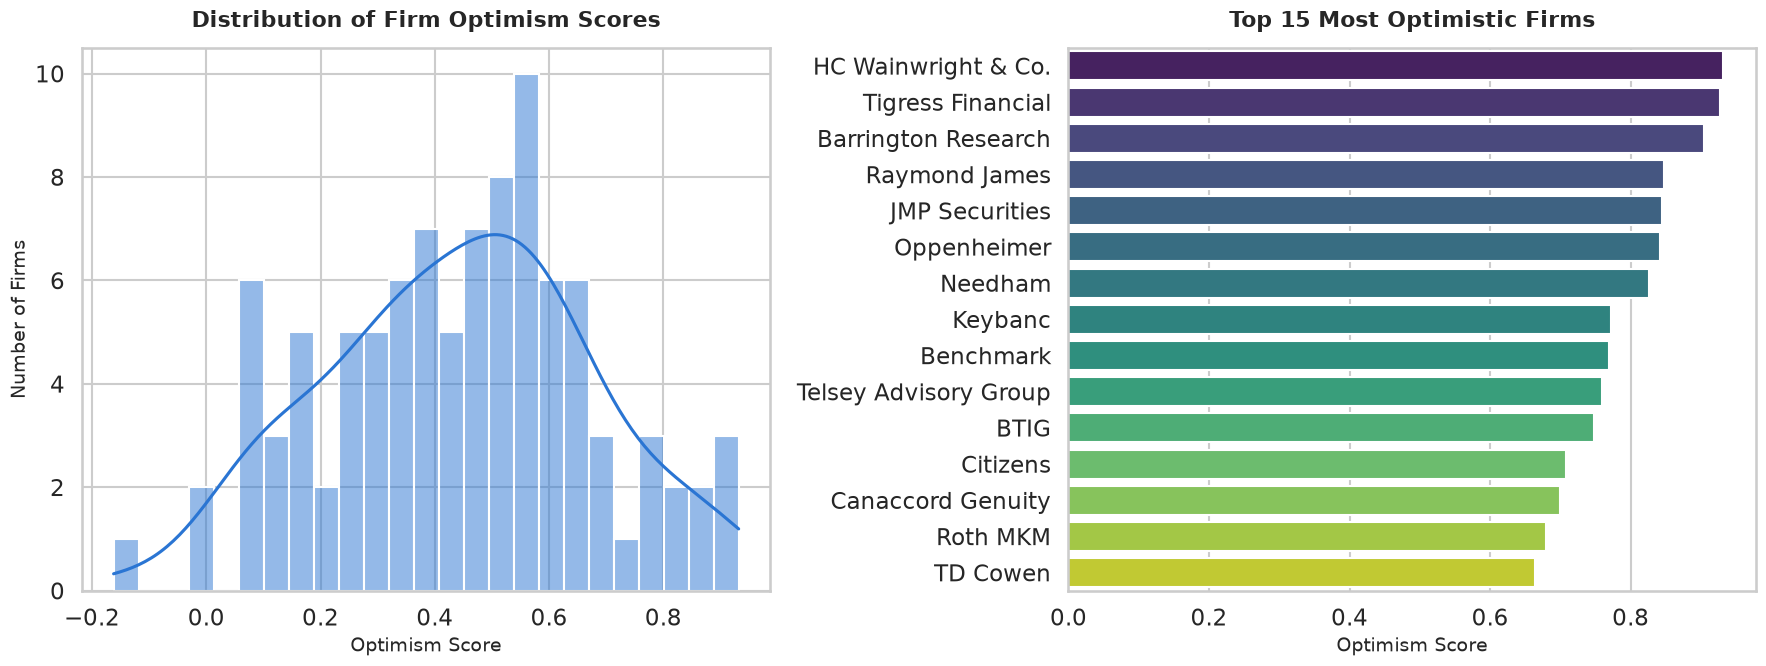

In [49]:
firm_optimism = firm_optimism[firm_optimism['total_predictions'] > 50]

sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.histplot(
    data=firm_optimism,
    x='optimism_score',
    bins=25,
    kde=True,
    color='#2A75D3',
    ax=axes[0]
)
axes[0].set_title('Distribution of Firm Optimism Scores', fontsize=16, pad=15, fontweight='bold')
axes[0].set_xlabel('Optimism Score', fontsize=14)
axes[0].set_ylabel('Number of Firms', fontsize=14)

sns.barplot(
    data=firm_optimism.head(15),
    x='optimism_score',
    y='firm',
    hue='firm',
    palette='viridis',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Top 15 Most Optimistic Firms', fontsize=16, pad=15, fontweight='bold')
axes[1].set_xlabel('Optimism Score', fontsize=14)
axes[1].set_ylabel('') 

plt.tight_layout()
plt.show()

### Prediction Accuracy

The dataset contains a very clear binary indicator of accuracy at the 30, 90, 180, and 365 day horizons.

The ```DataFrame.agg``` function resolves null values (```NaN```, ```None```) by excluding them from calculations completely. This works for this application.

In [50]:
firm_accuracy = df.groupby('firm').agg(
    total_predictions=('implied_direction', 'count'),
    accuracy_30d_score=('accuracy_30d', 'mean'),
    accuracy_90d_score=('accuracy_90d', 'mean'),
    accuracy_180d_score=('accuracy_180d', 'mean'),
    accuracy_365d_score=('accuracy_365d', 'mean')
).sort_values(by='accuracy_180d_score', ascending=False)
firm_accuracy.sample(10)

,total_predictions,accuracy_30d_score,accuracy_90d_score,accuracy_180d_score,accuracy_365d_score
firm,,,,,
HC Wainwright & Co.,88,0.534884,0.612500,0.638889,0.546875
UBS,6511,0.553202,0.578820,0.590447,0.619248
Loop Capital,761,0.500986,0.594810,0.646586,0.639413
SVB Leerink,357,0.593750,0.638393,0.642857,0.638393
OTR Global,74,0.513514,0.581081,0.364865,0.337838
Empire Asset Management,1,0.000000,0.000000,0.000000,0.000000
MLV & Co.,1,1.000000,1.000000,1.000000,1.000000
Deutsche bank,3,1.000000,0.333333,0.333333,0.333333
Citizens Capital Markets,27,0.285714,0.666667,0.761905,0.238095


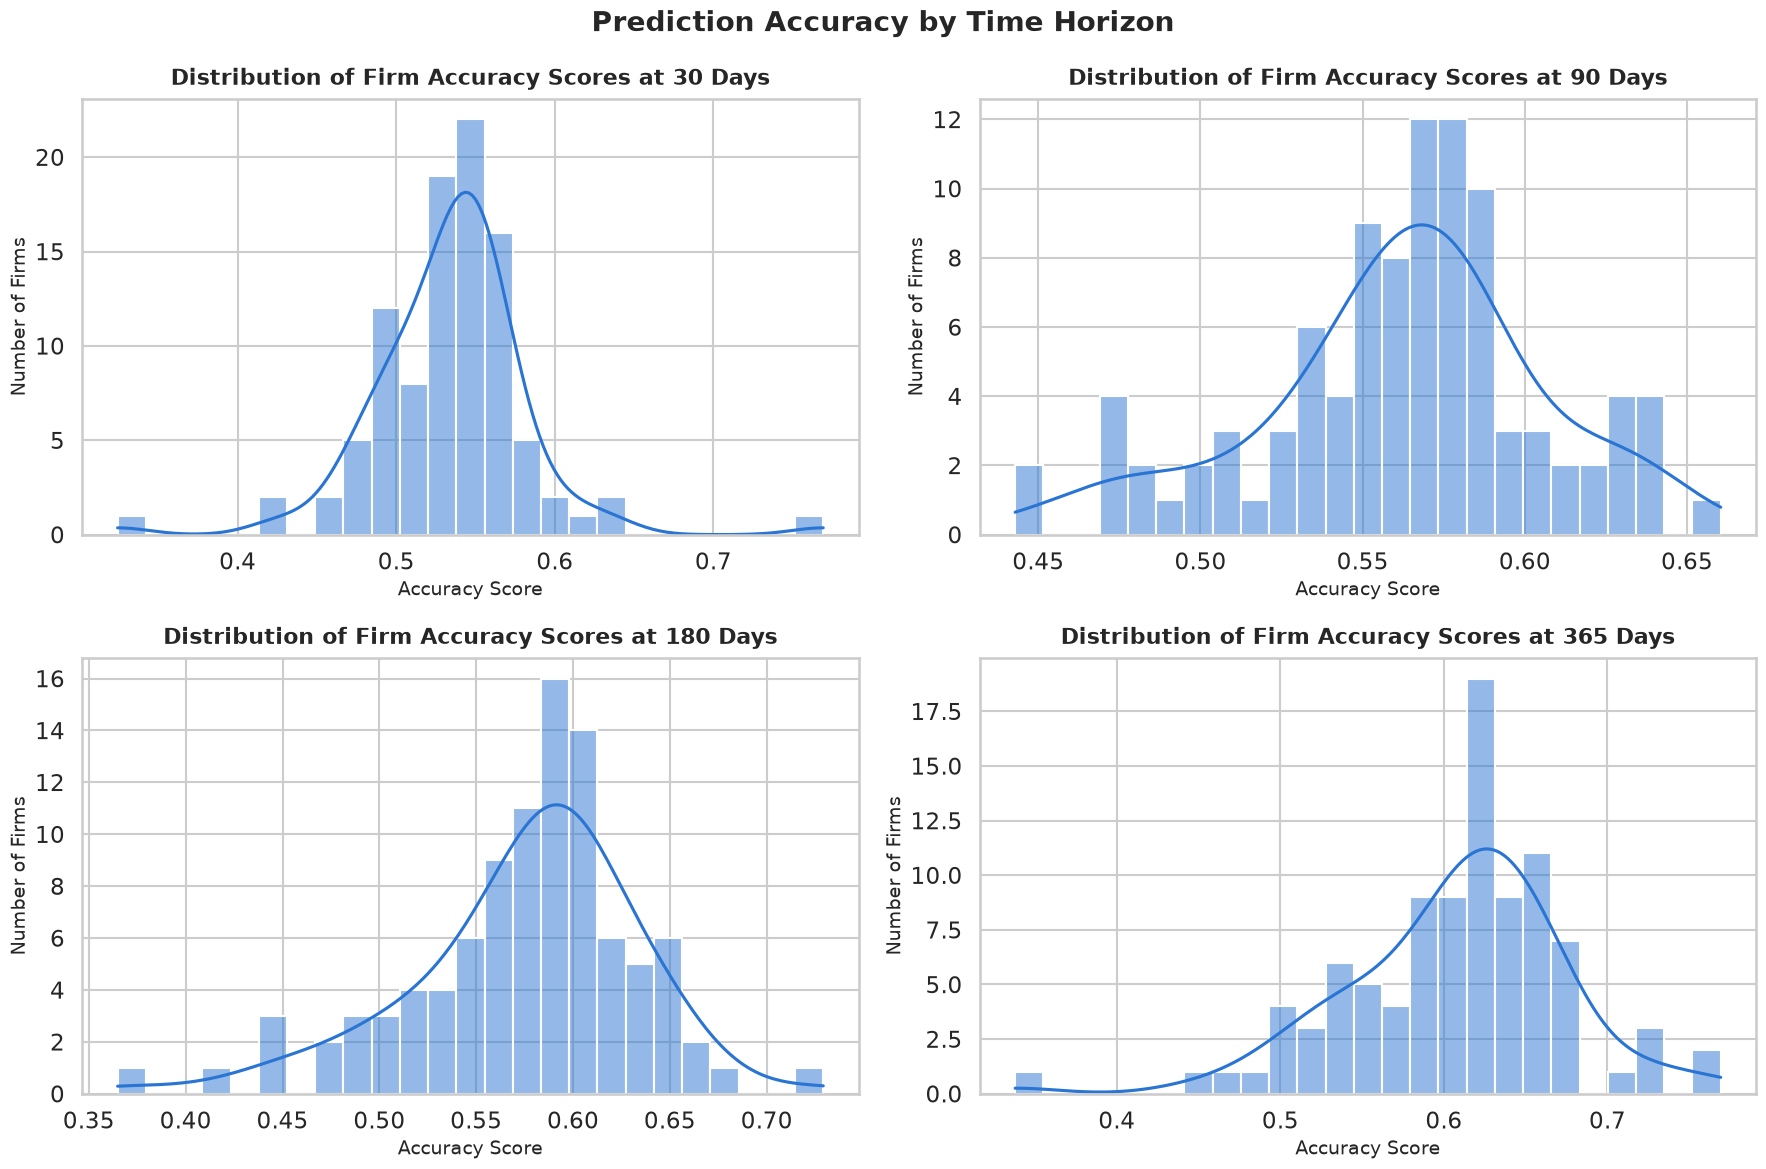

In [51]:
firm_accuracy = firm_accuracy[firm_accuracy['total_predictions'] > 50]

sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Prediction Accuracy by Time Horizon', fontsize=20, fontweight='bold')

def plot_histogram_reg(data, x, ax, title):
    sns.histplot(
        data=data,
        x=x,
        bins=25,
        kde=True,
        color='#2A75D3',
        ax=ax
    )
    ax.set_title(title, fontsize=16, pad=10, fontweight='bold')
    ax.set_xlabel('Accuracy Score', fontsize=14)
    ax.set_ylabel('Number of Firms', fontsize=14)

plot_histogram_reg(firm_accuracy, 'accuracy_30d_score', axes[0][0], 'Distribution of Firm Accuracy Scores at 30 Days')
plot_histogram_reg(firm_accuracy, 'accuracy_90d_score', axes[0][1], 'Distribution of Firm Accuracy Scores at 90 Days')
plot_histogram_reg(firm_accuracy, 'accuracy_180d_score', axes[1][0], 'Distribution of Firm Accuracy Scores at 180 Days')
plot_histogram_reg(firm_accuracy, 'accuracy_365d_score', axes[1][1], 'Distribution of Firm Accuracy Scores at 365 Days')

plt.tight_layout()
plt.show()

### Optimism X Accuracy

Attempt to visually identify any correlations between optimism and accuracy.

Begin by merging the ```firm_optimism``` and ```firm_accuracy``` data. Look for visual indications of correlation using a scatterplot.

In [52]:
firm_analysis = pd.merge(
    firm_optimism,
    firm_accuracy.drop(columns=['total_predictions']),
    left_index=True,
    right_index=True
)
firm_analysis.sample(10)

,total_predictions,optimism_score,accuracy_30d_score,accuracy_90d_score,accuracy_180d_score,accuracy_365d_score
firm,,,,,,
Craig-Hallum,129,0.465116,0.491525,0.559322,0.564103,0.640351
TD Securities,101,0.386139,0.769231,0.630769,0.523077,0.538462
Raymond James,3300,0.848182,0.553913,0.585834,0.635826,0.658273
Melius Research,85,0.505882,0.608696,0.636364,0.562500,0.575000
Benchmark,770,0.768831,0.539886,0.544379,0.605263,0.624785
Exane BNP Paribas,205,0.009756,0.489130,0.500000,0.527174,0.508197
Roth Capital,127,0.496063,0.553398,0.529412,0.582418,0.482759
Odeon Capital,54,0.166667,0.509804,0.490196,0.470588,0.470588
RBC Capital,5213,0.561673,0.558782,0.575641,0.589357,0.626486


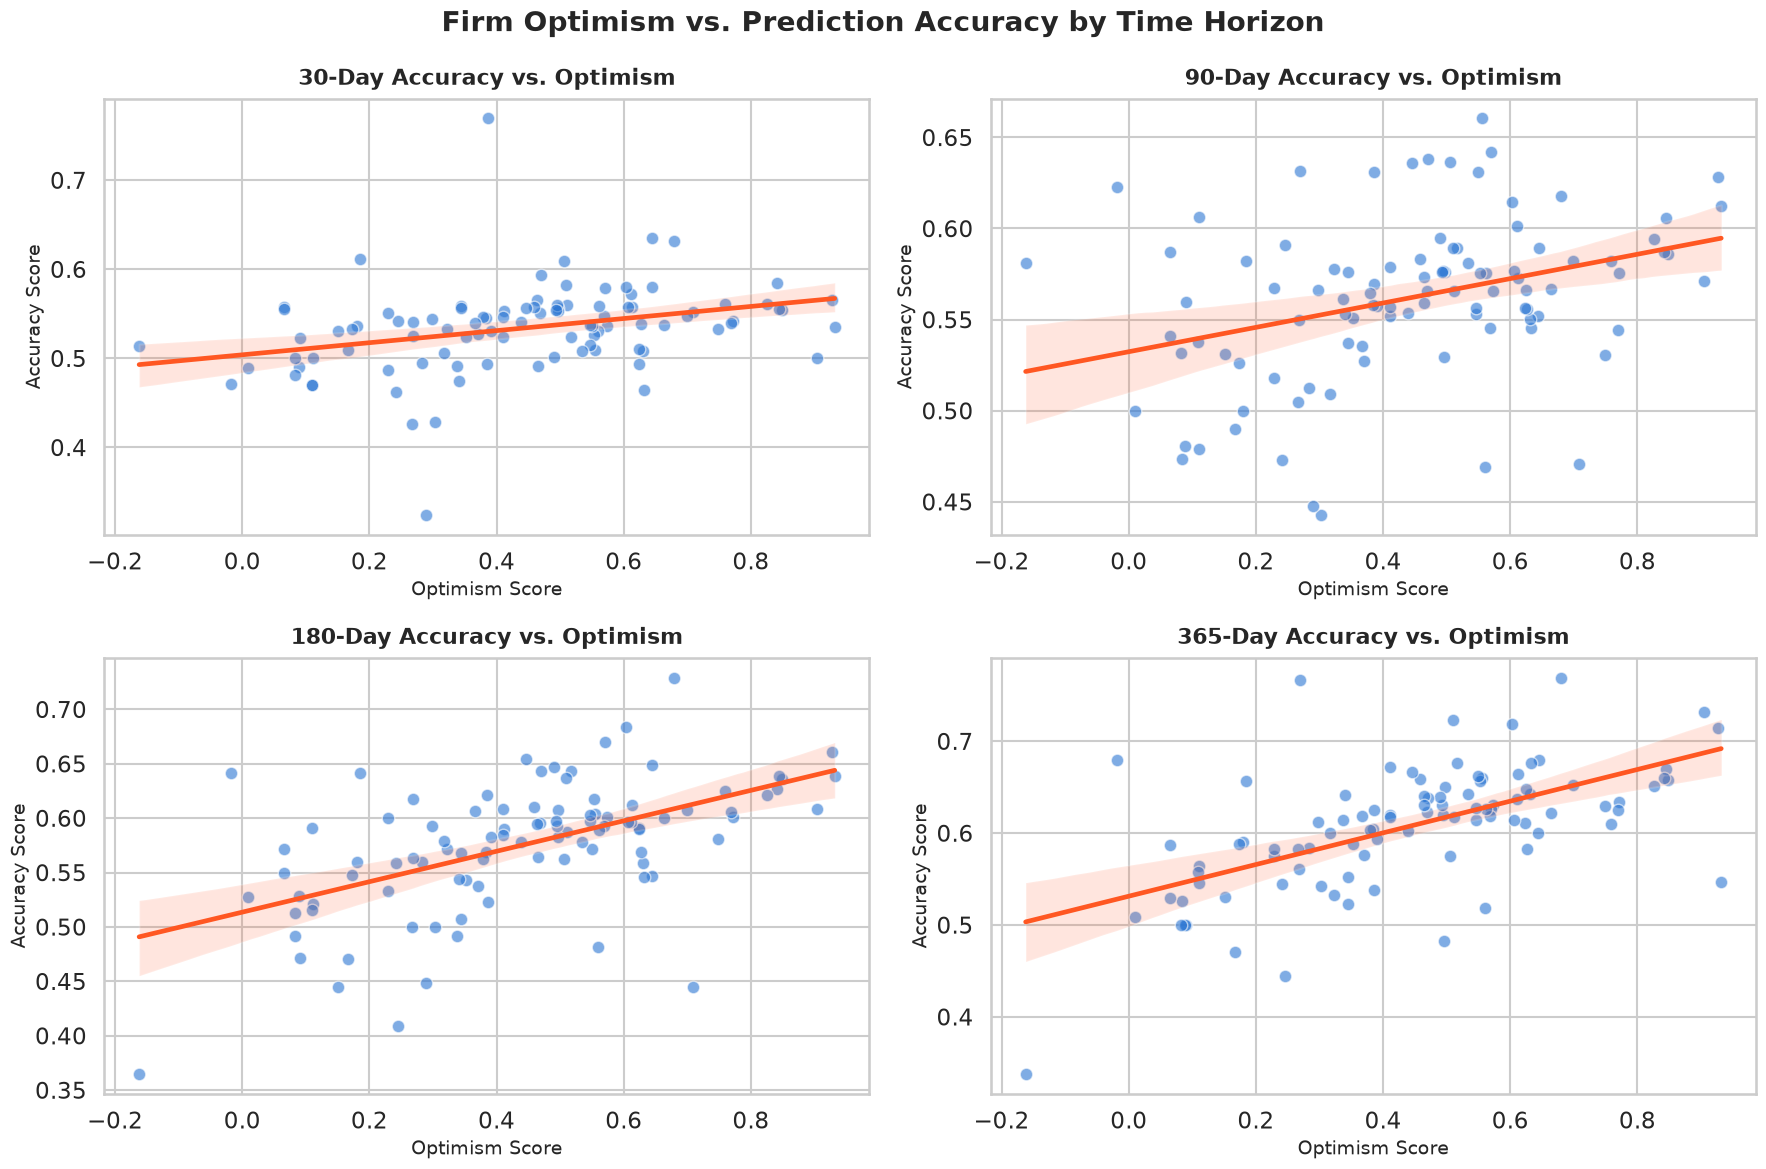

In [53]:
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Firm Optimism vs. Prediction Accuracy by Time Horizon', fontsize=20, fontweight='bold')

def plot_scatter_reg(data, x, y, ax, title):
    sns.regplot(
        data=data,
        x=x,
        y=y,
        ax=ax,
        color='#2A75D3',
        scatter_kws={'alpha': 0.6, 'edgecolor': 'w'},
        line_kws={'color': '#FF5722'}
    )
    ax.set_title(title, fontsize=16, pad=10, fontweight='bold')
    ax.set_xlabel('Optimism Score', fontsize=14)
    ax.set_ylabel('Accuracy Score', fontsize=14)

plot_scatter_reg(firm_analysis, 'optimism_score', 'accuracy_30d_score', axes[0][0], '30-Day Accuracy vs. Optimism')
plot_scatter_reg(firm_analysis, 'optimism_score', 'accuracy_90d_score', axes[0][1], '90-Day Accuracy vs. Optimism')
plot_scatter_reg(firm_analysis, 'optimism_score', 'accuracy_180d_score', axes[1][0], '180-Day Accuracy vs. Optimism')
plot_scatter_reg(firm_analysis, 'optimism_score', 'accuracy_365d_score', axes[1][1], '365-Day Accuracy vs. Optimism')

plt.tight_layout()
plt.show()

**Key Exploration Observation**: There is a clear trend line showing that firms that are more optimistic have greater accuracy.

## Pearson Correlation and p-value 

Calculate the Pearson Correlation and p-values for firm optimism vs. accuracy.

In [54]:
accuracy_cols = [
    'accuracy_30d_score', 
    'accuracy_90d_score', 
    'accuracy_180d_score', 
    'accuracy_365d_score'
]

stat_results = []

for col in accuracy_cols:
    valid_data = firm_analysis[['optimism_score', col]].dropna()
    
    corr, p_value = pearsonr(valid_data['optimism_score'], valid_data[col])
    
    stat_results.append({
        'Time Horizon': col.replace('accuracy_', '').replace('_score', ''),
        'Pearson Correlation (r)': corr,
        'p-value': p_value
    })

stats_df = pd.DataFrame(stat_results)

stats_df

,Time Horizon,Pearson Correlation (r),p-value
0,30d,0.318881,1.373132e-03
1,90d,0.352115,3.770936e-04
2,180d,0.546067,6.040814e-09
3,365d,0.593637,1.836566e-10


**Pivotal Observation**: The hypothesis has a *moderate* degree of correlation and is *very* likely accurate.

## Correlation During Downturns

This section will attempt to identify any correlation between analyst optimism and predictions in a market downturn.

In [58]:
is_downturn = pd.Series(False, index=df.index)

for _, row in downturns_df.iterrows():
    window_mask = (df['event_date'] >= row['Start Date']) & (df['event_date'] <= row['End Date'])
    is_downturn = is_downturn | window_mask

downturn_df = df[is_downturn]

print(f"Total predictions during downturns: {downturn_df.shape[0]}")

Total predictions during downturns: 22577


In [60]:
downturn_optimism = downturn_df.groupby('firm').agg(
    total_predictions=('implied_direction', 'count'),
    optimism_score=('implied_direction', 'mean')
)

downturn_accuracy = downturn_df.groupby('firm').agg(
    accuracy_30d_score=('accuracy_30d', 'mean'),
    accuracy_90d_score=('accuracy_90d', 'mean'),
    accuracy_180d_score=('accuracy_180d', 'mean'),
    accuracy_365d_score=('accuracy_365d', 'mean')
)

downturn_analysis = pd.merge(
    downturn_optimism,
    downturn_accuracy,
    left_index=True,
    right_index=True
)

downturn_analysis = downturn_analysis[downturn_analysis['total_predictions'] >= 15]

downturn_stats = []

for col in accuracy_cols:
    valid_data = downturn_analysis[['optimism_score', col]].dropna()
    
    corr, p_value = pearsonr(valid_data['optimism_score'], valid_data[col])
    
    downturn_stats.append({
        'Time Horizon': col.replace('accuracy_', '').replace('_score', ''),
        'Pearson Correlation (r)': round(corr, 4),
        'p-value': round(p_value, 4),
    })

downturn_stats_df = pd.DataFrame(downturn_stats)
downturn_stats_df

,Time Horizon,Pearson Correlation (r),p-value
0,30d,-0.2718,0.0161
1,90d,-0.2468,0.0294
2,180d,-0.0283,0.8056
3,365d,0.0505,0.6608


**Observation**: In the short term (30d and 90d time horizons), there is a statistically significant *negative* correlation. However, that correlation dissolves as time goes on to become ambiguous.

## Conclusion



## References

Evest. (2025 December 8). Opening price and closing price. Evest Trading Blog. https://www.evest.com/en/trading-blog/opening-price-and-closing-price

Yardeni Research. (2024 January 21). Stock market historical tables: Bull & bear markets. 
https://old.yardeni.com/wp-content/uploads/BullBearTables.pdf